In [1]:
import json
import glob
import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import figure_styles

In [6]:
depth_arr = [2, 4, 6, 8]
depth_iters = [2, 10]
num_files = 10
bond_dim = 32
weights = [5, 4]
gn = "N40R3R_"
problems = ["MIS_", "MC_"]
MPS_method = "MPS"
graph_repo = "../data/training/random_regular"
params = ["energy"]
# methods = ["TQA_SV_opt", "FA_SV_noOpt", "I_SV", "F_SV", "TS_SV", "FA_rescaled_SV", "FA_SV_opt", "F_refined_SV"]
# methods_l = ["TQA*", "Fixed Angles", "INTERP", "Fourier", "Transition States", "FA rescaled", "Fixed Angles*", "Refined Fourier"]
methods = ["TQA_SV_opt", "I_SV", "F_SV", "TS_SV", "FA_SV_opt"]
methods_l = ["TQA*", "INTERP", "Fourier", "Transition States", "Fixed Angles*"]
METHOD_LEGEND_TITLE = "Parameter setting method"
EVALUATION_LEGEND_TITLE = "Energy evaluation method"

missing_reports = []

In [7]:
def load_json_by_partial_name(partial_name: str, directory: str = ".", report_missing: bool = True):
    """Return (data, True) if found, else (None, False). Optionally report to missing_reports if not found."""
    pattern = os.path.join(directory, f"*{partial_name}*.json")
    matches = glob.glob(pattern)
    if not matches:
        if report_missing:
            missing_reports.append(f"No JSON files matching: {partial_name} (in {directory})")
        return None, False
    try:
        latest = max(
            matches,
            key=lambda s: int(m.group()) if (m := re.search(r"(\d+)(?=\.json$)", s)) else -1,
        )
    except (ValueError, TypeError):
        latest = matches[0]
    with open(latest) as f:
        return json.load(f), True


def load_json_by_partial_name_multi_dir(partial_name: str, directories: list):
    """Try each directory; return (data, True) on first match, else (None, False). Report missing once if all fail."""
    for directory in directories:
        d = os.path.normpath(os.path.abspath(directory)) if directory else directory
        pattern = os.path.join(d, f"*{partial_name}*.json")
        matches = glob.glob(pattern)
        if matches:
            try:
                latest = max(
                    matches,
                    key=lambda s: int(m.group()) if (m := re.search(r"(\d+)(?=\.json$)", s)) else -1,
                )
            except (ValueError, TypeError):
                latest = matches[0]
            with open(latest) as f:
                return json.load(f), True
    missing_reports.append(f"No JSON files matching: {partial_name} (tried: {directories})")
    return None, False


# Result arrays: use nan so missing data is excluded from mean/std
def nan_array(shape):
    a = np.empty(shape)
    a.fill(np.nan)
    return a

In [8]:
res_TQA_MPS = nan_array((num_files, len(depth_arr), len(params), len(problems)))
res_TQA_MPS_opt = nan_array((num_files, len(depth_arr), len(params), len(problems)))
res_FA_MPS = nan_array((num_files, len(depth_arr), len(params), len(problems)))
res_FA_MPS_opt = nan_array((num_files, len(depth_arr), len(params), len(problems)))
res_I_MPS = nan_array((num_files, len(depth_arr), len(params), len(problems)))
res_F_MPS = nan_array((num_files, len(depth_arr), len(params), len(problems)))
# res_TQA_PP = nan_array((num_files, len(depth_arr), len(params), len(problems)))
# res_TQA_PP_opt = nan_array((num_files, len(depth_arr), len(params), len(problems)))
# res_FA_PP = nan_array((num_files, len(depth_arr), len(params), len(problems)))
# res_FA_PP_opt = nan_array((num_files, len(depth_arr), len(params), len(problems)))
# res_I_PP = nan_array((num_files, len(depth_arr), len(params), len(problems)))
# res_F_PP = nan_array((num_files, len(depth_arr), len(params), len(problems)))
res_FA_rescaled_MPS = nan_array((num_files, len(depth_arr), len(params), len(problems)))
# res_FA_rescaled_PP = nan_array((num_files, len(depth_arr), len(params), len(problems)))

# Directories to search for FA_rescaled files (N40R3R naming, e.g. 003N40R3R_MIS_FA_rescaled_MPSAer_optBD32_2.json)
# Prefer script directory first so an example file next to the script is found
fa_rescaled_dirs = [
    ".",
    graph_repo,
    os.path.join(Path(graph_repo).parent, "random_regular"),
    ".",
]

for p, problem in enumerate(problems):
    w = weights[p]
    for n in range(num_files):
        r3r = "00" + str(n) + gn + problem

        data_I_MPS, _ = load_json_by_partial_name(r3r + f"I_{MPS_method}_optBD{bond_dim}", directory=graph_repo)
        # data_I_PP, _ = load_json_by_partial_name(r3r + f"I_PP_optMW{w}", directory=graph_repo)
        data_F_MPS, _ = load_json_by_partial_name(r3r + f"F_{MPS_method}_optBD{bond_dim}", directory=graph_repo)
        # data_F_PP, _ = load_json_by_partial_name(r3r + f"F_PP_optMW{w}", directory=graph_repo)

        for d in depth_arr:
            col = int(d / 2 - 1)
            data_TQA_MPS, _ = load_json_by_partial_name(
                r3r + f"TQA_{MPS_method}_optBD{bond_dim}_{d}", directory=graph_repo
            )
            # data_TQA_PP, _ = load_json_by_partial_name(r3r + f"TQA_PP_optMW{w}_{d}", directory=graph_repo)
            data_FA_MPS, _ = load_json_by_partial_name(
                r3r + f"FA_{MPS_method}_optBD{bond_dim}_{d}", directory=graph_repo
            )
            # data_FA_PP, _ = load_json_by_partial_name(r3r + f"FA_PP_optMW{w}_{d}", directory=graph_repo)
            # FA_rescaled: N40R3R naming, e.g. 003N40R3R_MIS_FA_rescaled_MPSAer_optBD32_2.json
            r3r_prefix = "00" + str(n) + "N40R3R_" + problem + "FA_rescaled_MPSAer_optBD" + str(bond_dim) + "_" + str(d)
            data_FA_rescaled_MPS, _ = load_json_by_partial_name_multi_dir(r3r_prefix, fa_rescaled_dirs)

            r3r_prefix = "00" + str(n) + "N40R3R_" + problem + "FA_rescaled_PP_optMW" + str(w) + "_" + str(d)
            # data_FA_rescaled_PP, _ = load_json_by_partial_name_multi_dir(r3r_prefix, fa_rescaled_dirs)

            for i in range(len(params)):
                if data_TQA_MPS is not None and "0" in data_TQA_MPS and "1" in data_TQA_MPS:
                    res_TQA_MPS[n, col, i, p] = data_TQA_MPS["0"][params[i]]
                    res_TQA_MPS_opt[n, col, i, p] = data_TQA_MPS["1"][params[i]]
                if data_FA_MPS is not None and "0" in data_FA_MPS and "1" in data_FA_MPS:
                    res_FA_MPS[n, col, i, p] = data_FA_MPS["0"][params[i]]
                    res_FA_MPS_opt[n, col, i, p] = data_FA_MPS["1"][params[i]]
                if data_FA_rescaled_MPS is not None and "0" in data_FA_rescaled_MPS and "1" in data_FA_rescaled_MPS and params[i] in data_FA_rescaled_MPS["0"] and params[i] in data_FA_rescaled_MPS["1"]:
                    res_FA_rescaled_MPS[n, col, i, p] = data_FA_rescaled_MPS["1"][params[i]]  # use optimized "1" like Fixed Angles*
                # if data_FA_rescaled_PP is not None and "0" in data_FA_rescaled_PP and "1" in data_FA_rescaled_PP and params[i] in data_FA_rescaled_PP["0"] and params[i] in data_FA_rescaled_PP["1"]:
                #     res_FA_rescaled_PP[n, col, i, p] = data_FA_rescaled_PP["1"][params[i]]  # use optimized "1" like Fixed Angles*
                
                
                # if data_TQA_PP is not None and "0" in data_TQA_PP and "1" in data_TQA_PP:
                #     res_TQA_PP[n, col, i, p] = data_TQA_PP["0"][params[i]]
                #     res_TQA_PP_opt[n, col, i, p] = data_TQA_PP["1"][params[i]]
                # if data_FA_PP is not None and "0" in data_FA_PP and "1" in data_FA_PP:
                #     res_FA_PP[n, col, i, p] = data_FA_PP["0"][params[i]]
                #     res_FA_PP_opt[n, col, i, p] = data_FA_PP["1"][params[i]]
                if data_I_MPS is not None and "2" in data_I_MPS and str(d) in data_I_MPS["2"] and params[i] in data_I_MPS["2"][str(d)]:
                    res_I_MPS[n, col, i, p] = data_I_MPS["2"][str(d)][params[i]]
                # if data_I_PP is not None and "2" in data_I_PP and str(d) in data_I_PP["2"] and params[i] in data_I_PP["2"][str(d)]:
                #     res_I_PP[n, col, i, p] = data_I_PP["2"][str(d)][params[i]]
                if data_F_MPS is not None and "2" in data_F_MPS and str(d) in data_F_MPS["2"] and params[i] in data_F_MPS["2"][str(d)]:
                    res_F_MPS[n, col, i, p] = data_F_MPS["2"][str(d)][params[i]]
                # if data_F_PP is not None and "2" in data_F_PP and str(d) in data_F_PP["2"] and params[i] in data_F_PP["2"][str(d)]:
                #     res_F_PP[n, col, i, p] = data_F_PP["2"][str(d)][params[i]]

if missing_reports:
    print("Missing files (plot will use available data only):")
    for msg in missing_reports:
        print(" ", msg)


Missing files (plot will use available data only):
  No JSON files matching: 000N40R3R_MIS_FA_rescaled_MPSAer_optBD32_2 (tried: ['.', '../data/training/random_regular', '../data/training/random_regular', '.'])
  No JSON files matching: 000N40R3R_MIS_FA_rescaled_MPSAer_optBD32_4 (tried: ['.', '../data/training/random_regular', '../data/training/random_regular', '.'])
  No JSON files matching: 000N40R3R_MIS_FA_rescaled_MPSAer_optBD32_6 (tried: ['.', '../data/training/random_regular', '../data/training/random_regular', '.'])
  No JSON files matching: 000N40R3R_MIS_FA_rescaled_MPSAer_optBD32_8 (tried: ['.', '../data/training/random_regular', '../data/training/random_regular', '.'])
  No JSON files matching: 001N40R3R_MIS_FA_rescaled_MPSAer_optBD32_2 (tried: ['.', '../data/training/random_regular', '../data/training/random_regular', '.'])
  No JSON files matching: 001N40R3R_MIS_FA_rescaled_MPSAer_optBD32_4 (tried: ['.', '../data/training/random_regular', '../data/training/random_regular', '

FA_SV_opt
FA_SV_opt
FA_SV_opt
FA_SV_opt
FA_SV_opt
I_SV
I_SV
F_SV
F_SV
I_SV
F_SV
F_SV
FA_SV_opt
I_SV
F_SV
I_SV
FA_SV_opt
F_SV
I_SV
FA_SV_opt
FA_SV_opt
FA_SV_opt
F_SV
I_SV
F_SV
I_SV
F_SV
I_SV
F_SV
I_SV
FA_SV_opt
FA_SV_opt
FA_SV_opt
FA_SV_opt
FA_SV_opt
F_SV
I_SV
FA_SV_opt
F_SV
I_SV
FA_SV_opt
F_SV
FA_SV_opt
I_SV
F_SV
FA_SV_opt
TQA_SV_opt
F_SV
F_SV
FA_SV_opt
I_SV
TQA_SV_opt
F_SV
FA_SV_opt
TQA_SV_opt
I_SV
F_SV
TQA_SV_opt
TQA_SV_opt
FA_SV_opt
F_SV
I_SV
FA_SV_opt
TQA_SV_opt
FA_SV_opt
TQA_SV_opt
I_SV
FA_SV_opt
TQA_SV_opt
TQA_SV_opt
F_SV
FA_SV_opt
I_SV
F_SV
FA_SV_opt
I_SV
F_SV
FA_SV_opt
I_SV
F_SV
I_SV
TQA_SV_opt
F_SV
I_SV
TQA_SV_opt
FA_SV_opt
F_SV
I_SV
F_SV
I_SV
TQA_SV_opt
FA_SV_opt
TQA_SV_opt
F_SV
FA_SV_opt
I_SV
TQA_SV_opt
FA_SV_opt
F_SV
TQA_SV_opt
FA_SV_opt
I_SV
FA_SV_opt
TQA_SV_opt
I_SV
TQA_SV_opt
F_SV
FA_SV_opt
TQA_SV_opt
I_SV
FA_SV_opt
F_SV
FA_SV_opt
F_SV
I_SV
F_SV
TQA_SV_opt
I_SV
F_SV
I_SV
TQA_SV_opt
F_SV
FA_SV_opt
I_SV
TQA_SV_opt
F_SV
I_SV
FA_SV_opt
TQA_SV_opt
I_SV
TQA_SV_opt
F_SV
FA_SV_o

/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_72466/1109504246.py:228: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


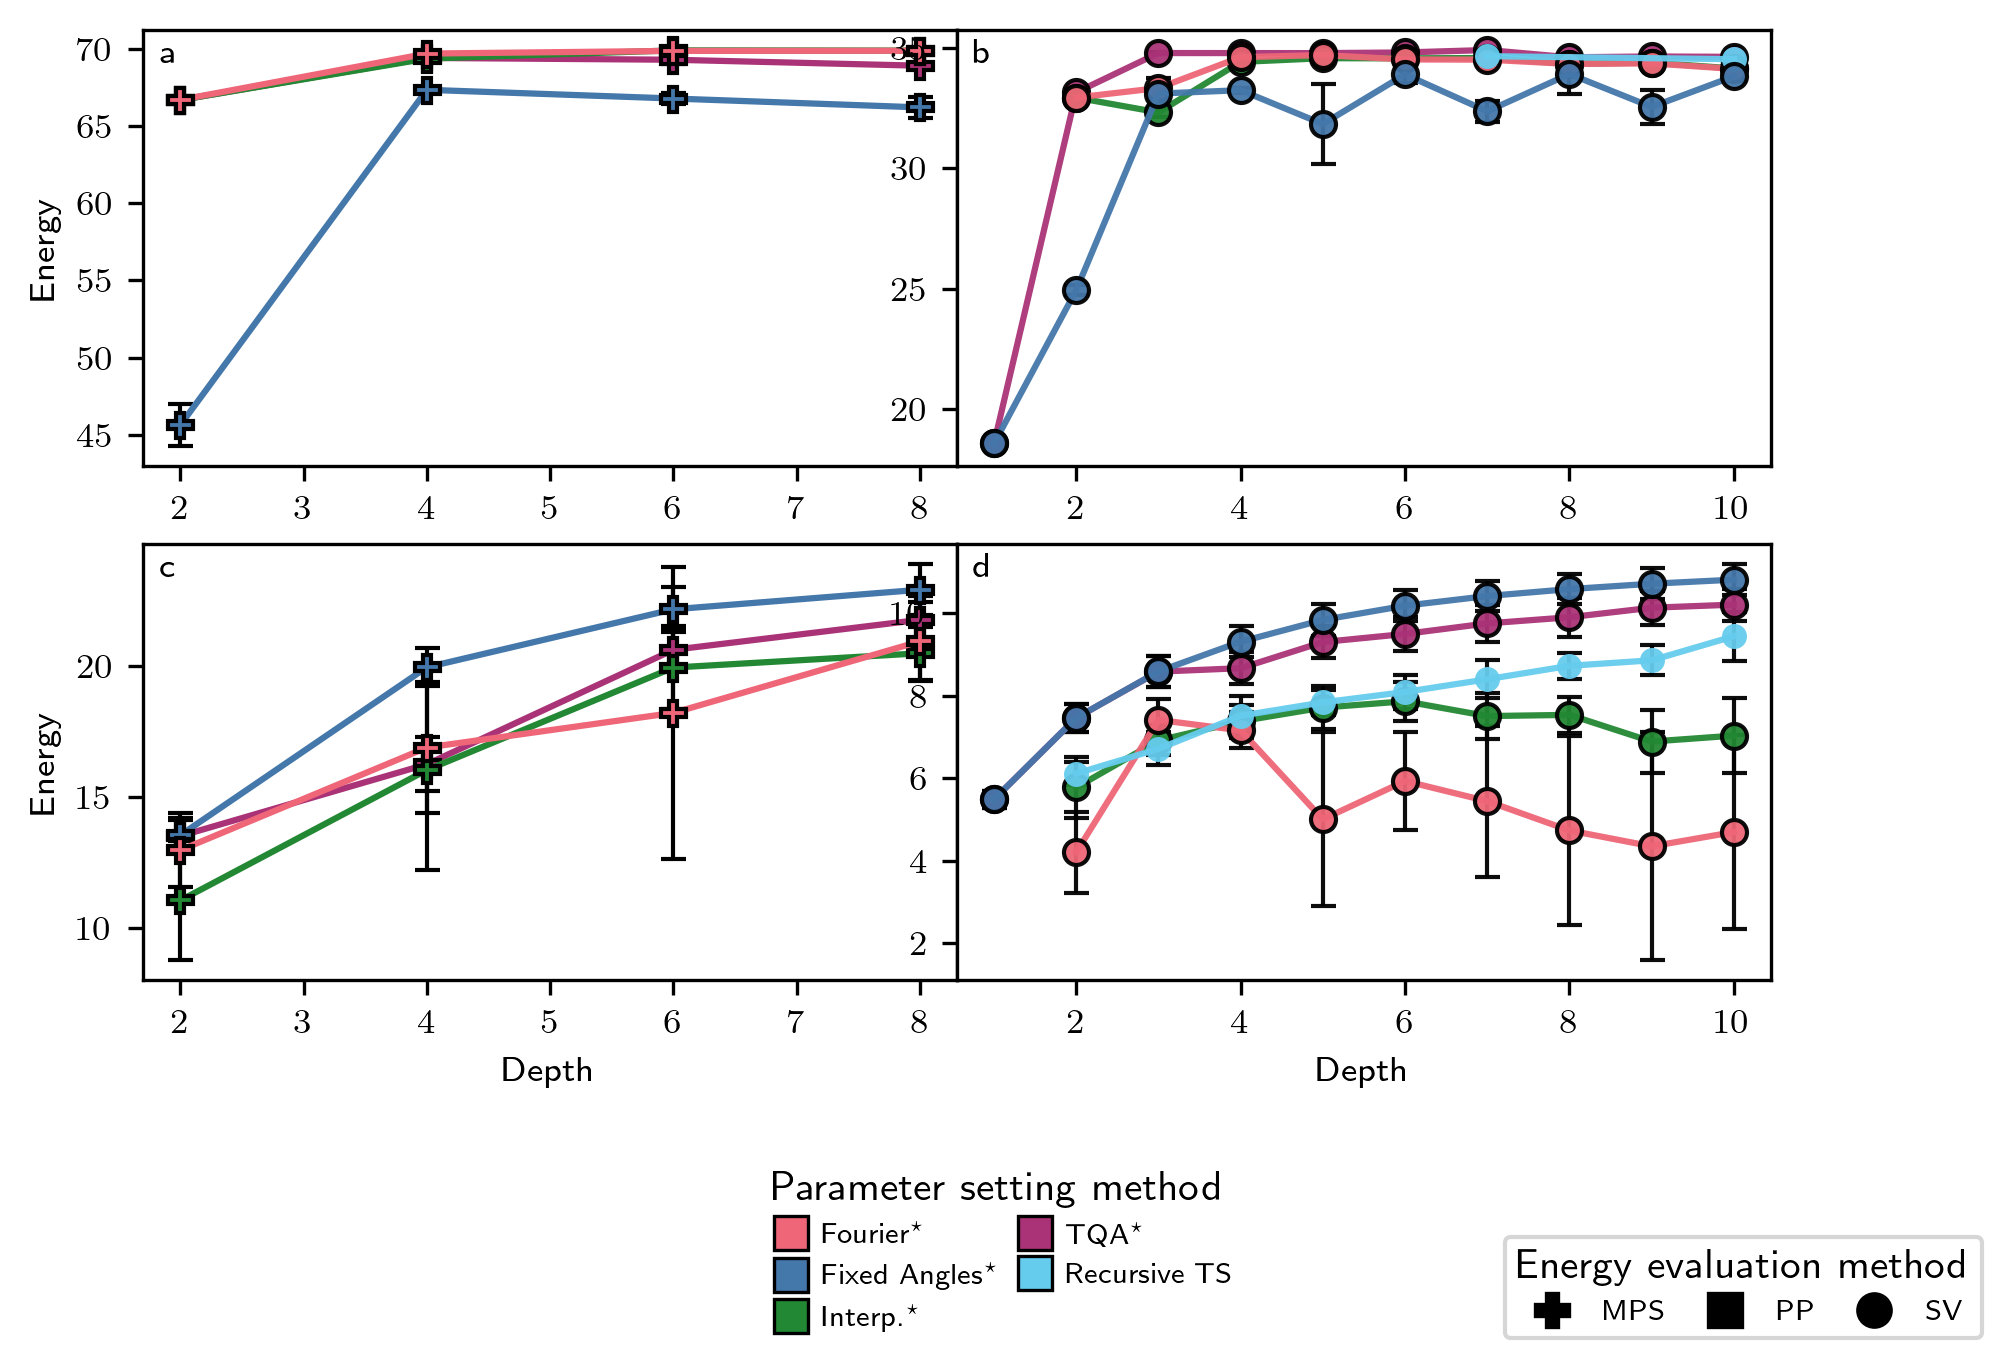

In [10]:
figure_styles.apply_rcparams()
fig, axs = plt.subplots(
    2,
    2,
    dpi=figure_styles.FIGURE_DPI,
    figsize=figure_styles.figsize(aspect_ratio=1/0.707, two_columns=True),
)
depth = depth_arr

# Safe mean/std over axis 0, ignoring nans
def nanmean_std(arr, axis=0):
    m = np.nanmean(arr, axis=axis)
    s = np.nanstd(arr, axis=axis)
    return m, s

for j in range(len(params)):
    for p in range(len(problems)):
        m, s = nanmean_std(res_TQA_MPS_opt[:, :, j, p])
        axs[p, 0].errorbar(
            depth,
            m,
            yerr=s,
            label=figure_styles.format_method_label("TQA*"),
            **figure_styles.style_errorbar("TQA*", "MPS"),
        )
        m, s = nanmean_std(res_FA_MPS_opt[:, :, j, p])
        axs[p, 0].errorbar(
            depth,
            m,
            yerr=s,
            label=figure_styles.format_method_label("Fixed Angles*"),
            **figure_styles.style_errorbar("Fixed Angles*", "MPS"),
        )
        m, s = nanmean_std(res_I_MPS[:, :, j, p])
        axs[p, 0].errorbar(
            depth,
            m,
            yerr=s,
            label=figure_styles.format_method_label("INTERP"),
            **figure_styles.style_errorbar("INTERP", "MPS"),
        )
        m, s = nanmean_std(res_F_MPS[:, :, j, p])
        axs[p, 0].errorbar(
            depth,
            m,
            yerr=s,
            label=figure_styles.format_method_label("Fourier"),
            **figure_styles.style_errorbar("Fourier", "MPS"),
        )


        # m, s = nanmean_std(res_TQA_PP_opt[:, :, j, p])
        # axs[p, 1].errorbar(
        #     depth,
        #     m,
        #     yerr=s,
        #     label=figure_styles.format_method_label("TQA*"),
        #     **figure_styles.style_errorbar("TQA*", "PP"),
        # )
        # m, s = nanmean_std(res_FA_PP_opt[:, :, j, p])
        # axs[p, 1].errorbar(
        #     depth,
        #     m,
        #     yerr=s,
        #     label=figure_styles.format_method_label("Fixed Angles*"),
        #     **figure_styles.style_errorbar("Fixed Angles*", "PP"),
        # )
        # m, s = nanmean_std(res_I_PP[:, :, j, p])
        # axs[p, 1].errorbar(
        #     depth,
        #     m,
        #     yerr=s,
        #     label=figure_styles.format_method_label("INTERP"),
        #     **figure_styles.style_errorbar("INTERP", "PP"),
        # )
        # m, s = nanmean_std(res_F_PP[:, :, j, p])
        # axs[p, 1].errorbar(
        #     depth,
        #     m,
        #     yerr=s,
        #     label=figure_styles.format_method_label("Fourier"),
        #     **figure_styles.style_errorbar("Fourier", "PP"),
        # )

        axs[p, 0].set_ylabel("Energy")

axs[1, 0].set_xlabel("Depth")
axs[1, 1].set_xlabel("Depth")
# axs[1, 2].set_xlabel("Depth")

# ---------------------------------------------------------------------------
# Joel's code: SV data from JSON files (MIS and MC), plot on right column
# ---------------------------------------------------------------------------
data_dir_2 = Path("../data/training/random_regular")
#data_dir_2 = Path("results_figure_MIS")
size_allowed = 20
fam_param_allowed = "R3R"


def collect_sv_energy_by_depth(files_glob, data_dir):
    """Return dict method -> {depth -> list of energies}. Skips files that fail to load."""
    method_to_files = {t: [] for t in methods}
    for fp in sorted(data_dir.glob(files_glob)):
        low = fp.name.lower()
        for t in methods:
            if t.lower() in low:
                print(t)
                method_to_files[t].append(fp)
                break
    parsed = {}
    for fp in sum(method_to_files.values(), []):
        if fp in parsed:
            continue
        try:
            parsed[fp] = json.loads(fp.read_text())
        except Exception as e:
            print(f"[WARN] Skipping {fp.name}: {e}")
            continue
    points_D_method = {t: {} for t in methods}
    for m, fps in method_to_files.items():
        for fp in fps:
            data = parsed.get(fp)
            if not data:
                continue
            try:
                N = re.search(r"N(\d+)", fp.name).group(1)
                fam_param = re.search(
                    r"N\d+(ER\d+|HH\d+|L\d+S\d+|R\d+R)", Path(fp.name).stem, re.IGNORECASE
                ).group(1)
            except (AttributeError, IndexError):
                continue
            if int(N) != size_allowed or fam_param != fam_param_allowed:
                continue
            try:
                depth = re.search(r"_(\d+)$", Path(fp.name).stem).group(1)
            except (AttributeError, IndexError):
                continue
            E = data.get(list(data.keys())[-1], {}).get("energy")
            if E is None or E == "NA":
                continue
            try:
                points_D_method[m].setdefault(int(depth), []).append(float(E))
            except (TypeError, ValueError):
                continue
    return points_D_method


points_MIS = collect_sv_energy_by_depth("*N20R3R*MIS*.json", data_dir_2)
points_MC = collect_sv_energy_by_depth("*N20R3R*MC*.json", data_dir_2)

for i, m in enumerate(methods):
    D_to_vals = points_MIS.get(m, {})
    if not D_to_vals:
        continue
    xs = sorted(D_to_vals.keys())
    means = [float(np.mean(D_to_vals[k])) for k in xs]
    stds = [float(np.std(D_to_vals[k], ddof=0)) for k in xs]
    xs_arr = np.array(xs, dtype=float)
    axs[0, 1].errorbar(
        xs_arr,
        means,
        yerr=stds,
        alpha=0.95,
        label=figure_styles.format_method_label(methods_l[i]),
        **figure_styles.style_errorbar(methods_l[i], "SV"),
    )

for i, m in enumerate(methods):
    D_to_vals = points_MC.get(m, {})
    if not D_to_vals:
        continue
    xs = sorted(D_to_vals.keys())
    means = [float(np.mean(D_to_vals[k])) for k in xs]
    stds = [float(np.std(D_to_vals[k], ddof=0)) for k in xs]
    xs_arr = np.array(xs, dtype=float)
    axs[1, 1].errorbar(
        xs_arr,
        means,
        yerr=stds,
        alpha=0.95,
        label=figure_styles.format_method_label(methods_l[i]),
        **figure_styles.style_errorbar(methods_l[i], "SV"),
    )

# ---------------------------------------------------------------------------
# Labels and legends
# ---------------------------------------------------------------------------
method_legend_items = [
    ("Fourier", "Fourier"),
    ("Fixed Angles*", "Fixed Angles*"),
    ("INTERP", "INTERP"),
    ("TQA*", "TQA*"),
    ("Transition States", "Transition States"),
]

evaluation_legend_items = [
    ("MPS", "MPS"),
    ("PP", "PP"),
    ("SV", "SV"),
]

method_handles = [
    figure_styles.method_legend_handle(
        figure_styles.format_method_label(label),
        method,
    )
    for label, method in method_legend_items
]
evaluation_handles = [
    figure_styles.evaluation_legend_handle(label, evaluation)
    for label, evaluation in evaluation_legend_items
]

fig.legend(
    handles=method_handles,
    title=METHOD_LEGEND_TITLE,
    **figure_styles.method_legend_kwargs(),
)
fig.legend(
    handles=evaluation_handles,
    title=EVALUATION_LEGEND_TITLE,
    **figure_styles.evaluation_legend_kwargs(),
)

figure_styles.add_panel_labels(axs)
figure_styles.adjust_subplots_for_legend(fig)

fig.show()
